# 시계열 변환
- 로그 변환(log transformation)과 거듭곱 변환(power transformation) 둘 다 포함하는 유용한 변환은 박스-칵스(Box-Cox) 변환의 일종
$$
w_t =
\begin{cases}
\log(y_t), & \text{if } \lambda = 0 \\
\dfrac{y_t^{\lambda} - 1}{\lambda}, & \text{if } \lambda \neq 0
\end{cases}
$$

- 조건 
    - **양수 보장**: 로그 변환 뒤 예측을 하고 $\exp$로 되돌리면 예측치와 예측구간이 음수가 될 수 없다. 전기수요, 가격, 개수처럼 양수 시계열에 적합.
	- **비대칭 구간**: 변환-역변환 때문에 원래 스케일에서는 상단 쪽이 더 긴 비대칭 구간이 자연스럽게 생깁니다(현실적)

- 변환을 선택하고나면, 변환된 데이터를 예측함. 그리고, 원래의 눈금에 대한 예측치를 얻기 위해 변환을 되돌릴 (또는 역-변환(back transformation)) 필요가 있습니다. 
- 역 박스-칵스(Box-Cox) 변환
$$
y_t =
\begin{cases}
\exp(w_t), & \text{if } \lambda = 0 \\
\left(\lambda w_t + 1\right)^{\tfrac{1}{\lambda}}, & \text{if } \lambda \neq 0
\end{cases}
$$

### 편향조정
- 역-변환된 점예측값(point forecast)이 예측 분포의 평균이 되지 않는 문제 발생. 사실, 보통은 (변환된 공간에서 분포가 대칭이라고 가정할 때) 예측 분포(forecast distribution)의 중간값(median)이 될 것입니다. 여러 가지 목적에서, 중간값도 괜찮긴 합니다만, 종종 평균 예측값이 필요하기도 합니다. 예를 들면, 한 나라 전체에 대한 예측값을 내기 위해 다양한 지역들의 판매량 예측값을 더하고 싶을 수 있습니다. 평균은 합산 과정이지만, 중간값(median)은 그렇지 않습니다.
- 박스-칵스(Box-Cox) 변환에 대해, 역 변환된 평균
$$
y_t =
\begin{cases}
\exp(w_t)\,\Bigl[1 + \tfrac{\sigma^2 h}{2}\Bigr], & \lambda = 0 \\[1.2em]
\left(\lambda w_t + 1\right)^{\tfrac{1}{\lambda}}
\left[1 + \dfrac{\sigma^2 h (1-\lambda)}{2 (\lambda w_t + 1)^2}\right], & \lambda \neq 0
\end{cases}
$$
$\sigma_h^2$가 클수록 평균(보정) 과 중간값(단순 역변환) 의 차이가 커진다.


# 1980년부터 2019년까지 호주의 월별 테이크아웃 음식 지출 데이터셋

In [332]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset

# 1) fpp2::auscafe 불러오기 (인터넷 필요)
df = get_rdataset("auscafe", "fpp2").data
df

,time,value
0,1982.250000,0.3424
1,1982.333333,0.3421
2,1982.416667,0.3287
3,1982.500000,0.3385
4,1982.583333,0.3315
...,...,...
421,2017.333333,3.5986
422,2017.416667,3.5442
423,2017.500000,3.6981
424,2017.583333,3.7112


In [333]:
date_index = pd.date_range(start="1982-04", periods=len(df), freq="M")
ts = pd.Series(df.iloc[:,1].values, index=date_index)  # 첫 번째 열만 값으로 사용
ts.name = "auscafe"
ts

1982-04-30    0.3424
1982-05-31    0.3421
1982-06-30    0.3287
1982-07-31    0.3385
1982-08-31    0.3315
               ...  
2017-05-31    3.5986
2017-06-30    3.5442
2017-07-31    3.6981
2017-08-31    3.7112
2017-09-30    3.7297
Freq: M, Name: auscafe, Length: 426, dtype: float64

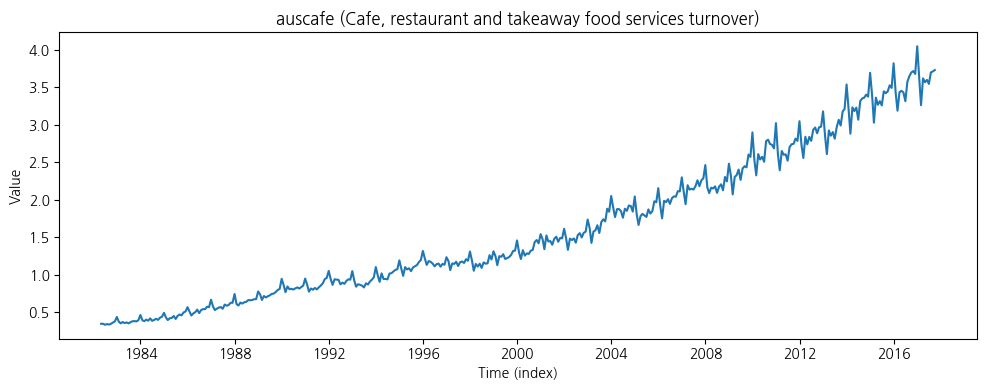

In [334]:
# 3) 단순 라인 플롯 (시계열 인덱스가 없으면 정수 인덱스로 그림)
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.title("auscafe (Cafe, restaurant and takeaway food services turnover)")
plt.xlabel("Time (index)")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

- 이 데이터는 계절성을 보이고 강력한 추세선을 가지고 있는 것을 알 수 있다.
- **계절적 변동과 무작위 변동의 크기가 시계열 수준에 따라 증가하는 것을 알 수 있다.** 따라서 가산 모델은 이 시계열을 설명하는 데 적합하지 않으므로 변환할 필요가 있다.
- 어떤 종류의 ARIMA 모델을 사용할지 추정하기 전에, 간단한 탐색적 데이터 분석(EDA)을 수행해야한다.

### Check stationarity and variance

- 정상 시계열인지 아닌지 분류 기준 3가지 
1. 시계열의 평균은 시간의 함수가 아니어야 합니다. 즉, 어느 정도의 분산은 모델링할 수 있지만 평균은 거의 일정해야 합니다. 
2. 시계열의 분산은 시간의 함수가 아니어야 합니다. 이러한 특성을 등분산성(homoscedasticity)이라고 합니다. 
3. 항의 공분산(예: k 번째 항과 (k + n) 번째 항)은 시간의 함수가 아니어야 합니다.

- 시계열이 비정상적임을 확인할 수 있는 두 가지 검정
1. Augmented Dickey-Fuller(ADF) 검정
2. Kwiatkowski-Phillips-Schmidt-Shin(KPSS) 검정

1. ADF 검정 
    - 귀무 가설 : 시계열 이 비정상적이거나 시계열에 단위근이 있다.
    - 대립 가설 : 시계열이 정상적이거나 시계열에 단위근이 없다.
    
**통계량이 임계값보다 작고 p-값이 0.05보다 작으면 귀무가설을 기각하여 시계열이 정상적임을 의미**

2. KPSS 검정
- 귀무가설: 해당 시계열은 정상(stationary) 시계열이다.
- 대립가설: 해당 시계열은 비정상(non-stationary) 시계열이다.

**통계량이 임계값보다 작고 p-값이 0.05보다 작으면 귀무가설을 기각하여 시계열이 비정상적임을 의미**

In [335]:
from statsmodels.tsa.stattools import adfuller

# df가 pandas Series 라고 가정 (예: auscafe 시계열)
result = adfuller(ts)

print("ADF Statistic: %f" % result[0])
print("p-value: %f" % result[1])
print("유의수준 0.05하에 귀무가설을 기각하지 못하고 시계열이 정상적이지 않고 단위근을 가진다.")

ADF Statistic: 3.048345
p-value: 1.000000
유의수준 0.05하에 귀무가설을 기각하지 못하고 시계열이 정상적이지 않고 단위근을 가진다.


In [504]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(ts)
print(kpss_result[1])
print("유의수준 0.05하에 귀무가설을 기각하여 시계열이 비정상적이다.")

0.01
유의수준 0.05하에 귀무가설을 기각하여 시계열이 비정상적이다.


KPSS 검정은 KPSS 검정 결과가 0.05 미만이기 때문에 시계열이 정상적이지 않다는 것을 나타냅니다.

두 검정의 귀무가설, 대립가설이 다르므로 유의해야한다.

diff방법을 사용하여 시계열을 차분하거나, Box-Cox 변환을 통해 추세를 제거할 수 있습니다.


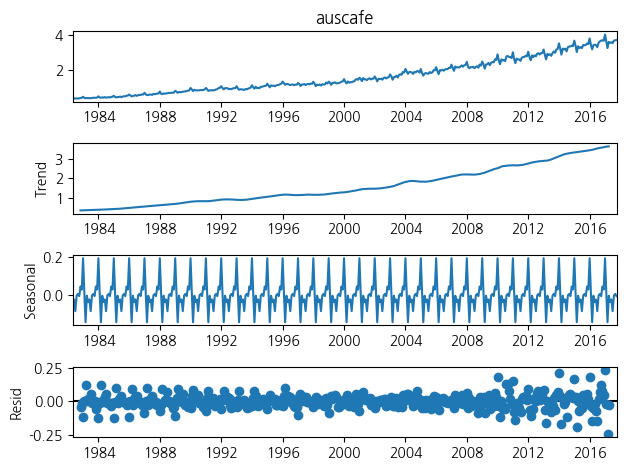

In [274]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(ts, model='additive', period=12)

# 2. 결과 시각화
fig = decomp.plot()
plt.show()

- 시계열에 추세와 계절적 요소가 포함되어있으며, 시계열의 분산이 시간이 지남에 따라 증가하는 것을 확인할 수 있다. ARIMA 모델은 계절성과 비정상성을 잘 처리하지만, 분산의 변화나 **이분산성을 특히 잘 처리하지는 못한다.**
- 시계열에서 **이분산성이 발생하면 이를 관리하기 위해 로그 변환**을 사용하는 것이 일반적입니다. 이를 위한 한 가지 도구는 박스-콕스 변환입니다. 이 BoxCox()방법은 다음과 같이 정의된 람다 매개변수를 사용합니다.

$$
w_t =
\begin{cases}
\log(y_t), & \text{if } \lambda = 0 \\
\dfrac{y_t^{\lambda} - 1}{\lambda}, & \text{if } \lambda \neq 0
\end{cases}
$$


In [337]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox, boxcox_normmax

# 1. 최적의 λ(lambda) 추정 (log-likelihood 최대화 방식)
lambda_opt = boxcox_normmax(ts, method='mle')
print(f"추정된 Box-Cox λ: {lambda_opt:.4f}")

s_trans = boxcox(ts, lmbda=lambda_opt)  # 앞에서 람다 값 구했으면 이렇게 

추정된 Box-Cox λ: 0.2212


In [277]:
# 2. Box-Cox 변환
s_trans, fitted_lambda = boxcox(ts)  # 굳이 안해도 바로 이렇게 해도 됨

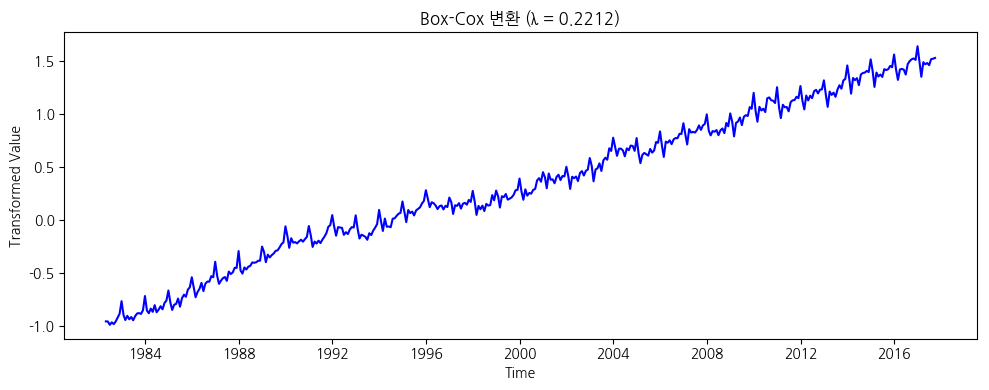

In [283]:
# 3. 시각화
plt.figure(figsize=(10,4))
plt.plot(ts.index, s_trans, color="blue")
plt.title(f"Box-Cox 변환 (λ = {lambda_opt:.4f})")
plt.xlabel("Time")
plt.ylabel("Transformed Value")
plt.tight_layout()
plt.show()

박스콕스 변환된 시계열의 계절적 변동과 무작위 변동의 크기가 시간에 따라 거의 일정하며 시계열 수준에 의존하지 않는 것을 알 수 있다.

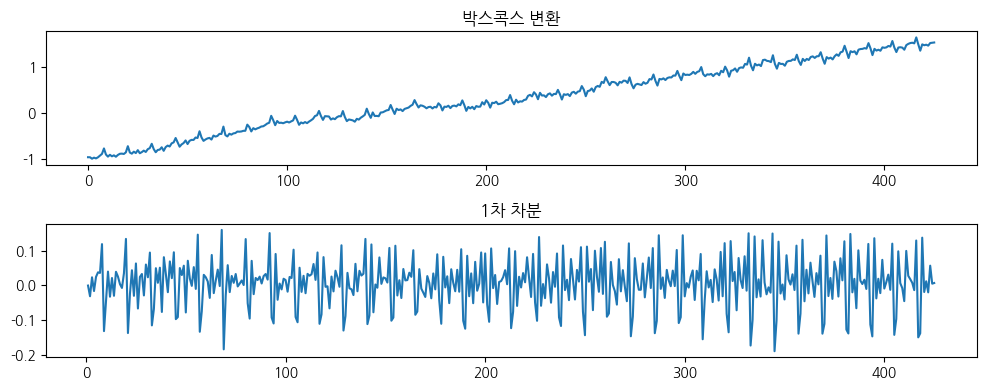

In [488]:
# 로그 + 1차 차분
ts_diff = pd.Series(s_trans).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 4))
axes[0].plot(s_trans); axes[0].set_title('박스콕스 변환')
axes[1].plot(ts_diff); axes[1].set_title('1차 차분')
plt.tight_layout(); plt.show()

In [489]:
from statsmodels.tsa.stattools import adfuller

# df가 pandas Series 라고 가정 (예: auscafe 시계열)
result = adfuller(ts_diff)

print("ADF Statistic: %f" % result[0])
print("p-value: %f" % result[1])

ADF Statistic: -6.454899
p-value: 0.000000


#  자기상관 관계 플롯

- 시계열 데이터에서 자기상관이 어디에 있는지 확인하여 시계열이 과거 값과 어느 정도 상관관계를 갖는지 확인할 수 있습니다. 
- 자기상관을 계산하면 데이터가 무작위성을 보이는지, 그리고 한 관측치가 바로 인접한 관측치와 얼마나 관련이 있는지에 대한 질문에 답할 수 있습니다.
- 이를 통해 어떤 유형의 모델이 데이터를 가장 잘 나타낼 수 있는지 파악할 수 있습니다. 자기상관은 종종 시차 단위까지(시차 단위 포함)의 상관관계를 파악하기 위해 그래프로 표시됩니다. 
- 자기상관 함수(ACF)와 부분 자기상관 함수(PACF)의 두 가지 접근 방식 존재한다.

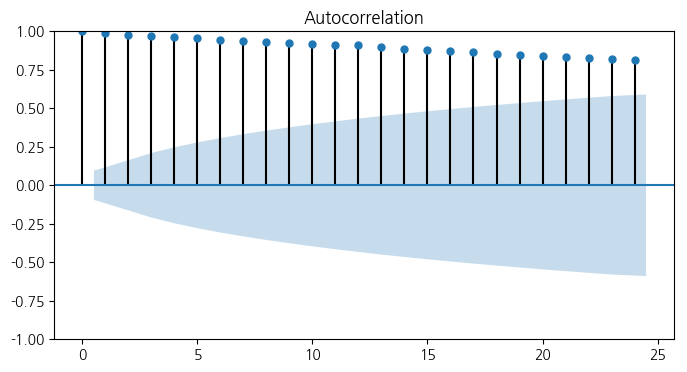

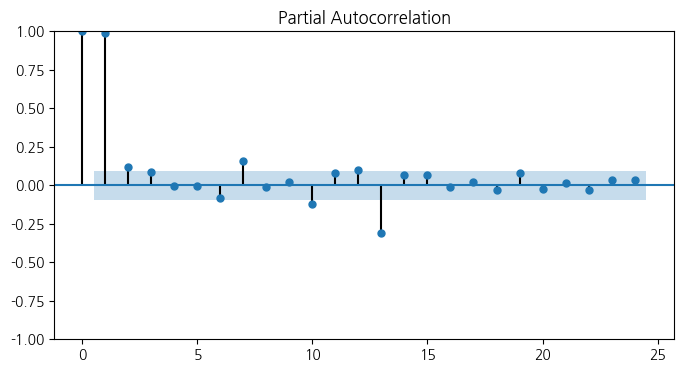

In [526]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

# transform 이 pandas Series 또는 ndarray라고 가정
fig, ax = plt.subplots(figsize=(8,4))
plot_acf(s_trans, lags=40, ax=ax)  # lags=40은 최대 지연 시차 (필요시 조정)
plt.show()

# transform 이 pandas Series 또는 ndarray라고 가정
fig, ax = plt.subplots(figsize=(8,4))
plot_pacf(s_trans, lags=40, method='ywm', ax=ax)  # lags 조정 가능
plt.show()

- ACF : 데이터 포인트가 강한 자기 상관관계를 가지고 있다. -> 더 높은 순위의 AR 구성요소를 사용할 가능성이 높다.
- PACF : 1.0 지연 이후 빠르게 떨어지는 것을 볼 수 있는데, 이는 1.0 이후의 지연이 덜 중요하다는 것을 나타냅니다.

- 두 플롯에서 ACF 플롯이 시차 1에서 양의 값을 보이고 PACF가 다소 빠르게 감소하는 것을 확인할 수 있다.. 이는 모델에 **AR 항**을 사용해야 함을 시사합니다.

- AR() 모형

    - ACF 플롯은 자기상관관계가 0에 가까워지는 것을 보여줍니다.
    - PACF 플롯은 0에 급격히 감소합니다.
    - 정상 시계열의 ACF 플롯은 시차 1에서 양의 값을 보여줍니다.
- MA() 모형
    - ACF는 지연 1에서 음의 자기상관관계를 보입니다.
    - 몇 번의 지연 후 급격히 떨어지는 ACF.
    - PACF는 갑자기 감소하는 것이 아니라 점진적으로 감소합니다.

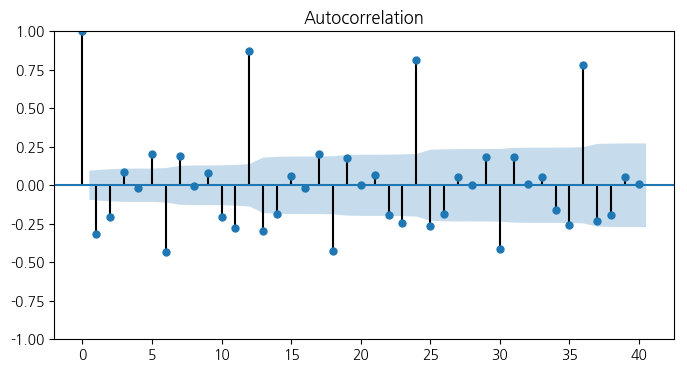

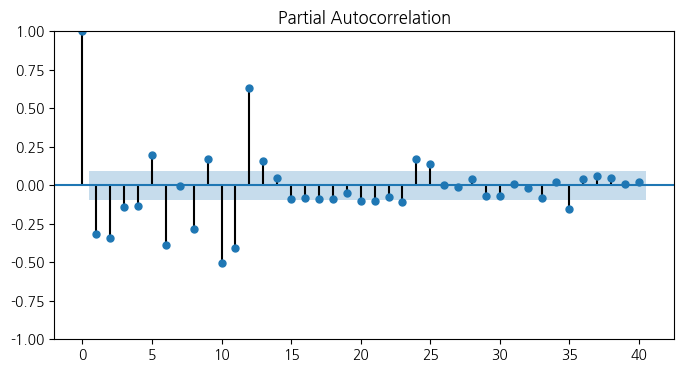

In [505]:
fig, ax = plt.subplots(figsize=(8,4))
plot_acf(ts_diff, lags=40, ax=ax)  # lags=40은 최대 지연 시차 (필요시 조정)
plt.show()

# transform 이 pandas Series 또는 ndarray라고 가정
fig, ax = plt.subplots(figsize=(8,4))
plot_pacf(ts_diff, lags=40, method='ywm', ax=ax)  # lags 조정 가능
plt.show()

ACF 그래프를 보면 시차 12 단위로 자기상관이 커짐을 알 수 있다. 이는 매우 큰 계절성을 의미한다.

# ARIMA 모델 학습
- 어떤 종류의 ARIMA 모델이 데이터를 잘 나타낼지 파악하기 위해 여러 모델을 실제로 학습시켜 테스트 데이터에서 성능을 비교

In [494]:
import numpy as np

n = len(s_trans)
# 80%까지 학습 데이터
train_size = int(round(n * 0.8))

train = s_trans[:train_size]
test = s_trans[train_size:]

h = len(test)
print(f"train 크기: {len(train)}")
print(f"test 크기: {len(test)} (h={h})")

train 크기: 341
test 크기: 85 (h=85)


In [495]:
import statsmodels.api as sm

non_seasonal_model = sm.tsa.ARIMA(train, order=(1, 1, 0)).fit()

print(non_seasonal_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  341
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 451.163
Date:                Sun, 31 Aug 2025   AIC                           -898.327
Time:                        19:36:32   BIC                           -890.669
Sample:                             0   HQIC                          -895.275
                                - 341                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3085      0.043     -7.154      0.000      -0.393      -0.224
sigma2         0.0041      0.000     12.526      0.000       0.003       0.005
Ljung-Box (L1) (Q):                   4.05   Jarque-

- sigma^2 : 잔차 값의 분산을 나타냅니다. 낮을수록 좋습니다.
- 로그 우도 : 이것은 ARIMA 모델에 대한 최대 우도 추정치이며 높을수록 좋습니다.
- aic : 모델의 적합도와 경제성을 측정하는 지표로, 낮을수록 좋음

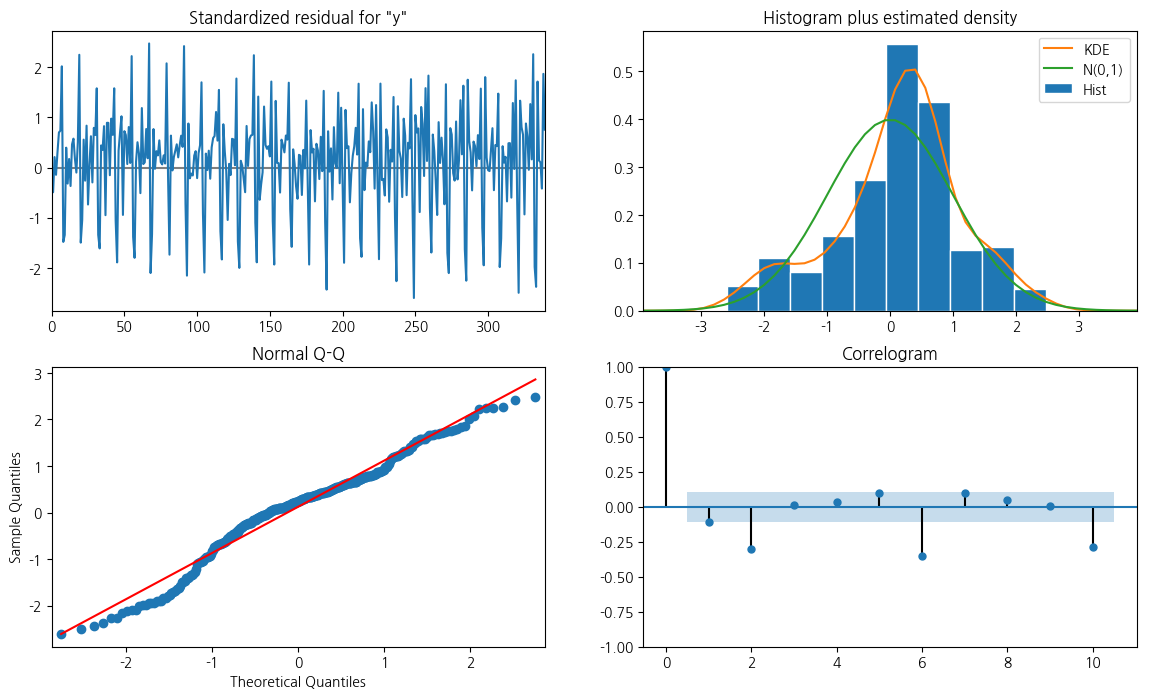

In [496]:
non_seasonal_model.plot_diagnostics(figsize=(14, 8))
pyplot.show()

In [498]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# 1. 잔차 추출
resid = non_seasonal_model.resid

# 4. Ljung-Box test
lb_test = acorr_ljungbox(resid, lags=[12], return_df=True)
print("\nLjung-Box test (lag=10):")
print(lb_test)


Ljung-Box test (lag=10):
       lb_stat     lb_pvalue
12  131.053194  3.792856e-22


잔차는 백색잡음이 아니다.

- ACF 그래프는 계절적 요인이 강하다는 것을 보여줍니다. 
- Ljung-Box test 귀무가설 : 잔차는 백색잡음이다. 귀무가설 기각되어 적합한 모형이 아니다. 
- 정규성을 만족하지 않는다.
- 이를 위해 계절적 ARIMA 모형을 만들어야한다. 

PACF 플롯은 플롯 간의 자기상관이 빠르게 감소함을 나타내므로, 시간의 계절적 구성 요소 간의 차이는 잡음과 자기상관 때문이라고 생각할 수 있습니다. 자기회귀 항과 이동평균 항을 모두 갖는 모형을 ARMA 모형이라고 합니다. 이는 계절적 구성 요소에 이동평균 항이 있음을 나타냅니다.

In [293]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import numpy as np

# 1. 계절형 ARIMA 적합 (SARIMAX)
# R의 seasonal=c(1,1,1) 은 (P,D,Q,s) 형태, 보통 s=주기(period) 지정 필요 (예: 월별=12)
seasonal_model = sm.tsa.SARIMAX(train,
                                order=(1,0,1),
                                seasonal_order=(0,1,1,12),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit()

print(seasonal_model.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.73849D+00    |proj g|=  8.73711D+00

At iterate    5    f= -1.76296D+00    |proj g|=  3.08705D+00

At iterate   10    f= -1.85778D+00    |proj g|=  1.41634D+00

At iterate   15    f= -1.97562D+00    |proj g|=  9.69956D+00

At iterate   20    f= -2.02163D+00    |proj g|=  2.27627D-01


 This problem is unconstrained.



At iterate   25    f= -2.04138D+00    |proj g|=  3.03119D+00

At iterate   30    f= -2.04400D+00    |proj g|=  1.81520D-02

At iterate   35    f= -2.04437D+00    |proj g|=  3.82873D-01

At iterate   40    f= -2.04466D+00    |proj g|=  9.14768D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     43     70      1     0     0   7.389D-04  -2.045D+00
  F =  -2.0446608806098046     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:               


   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.


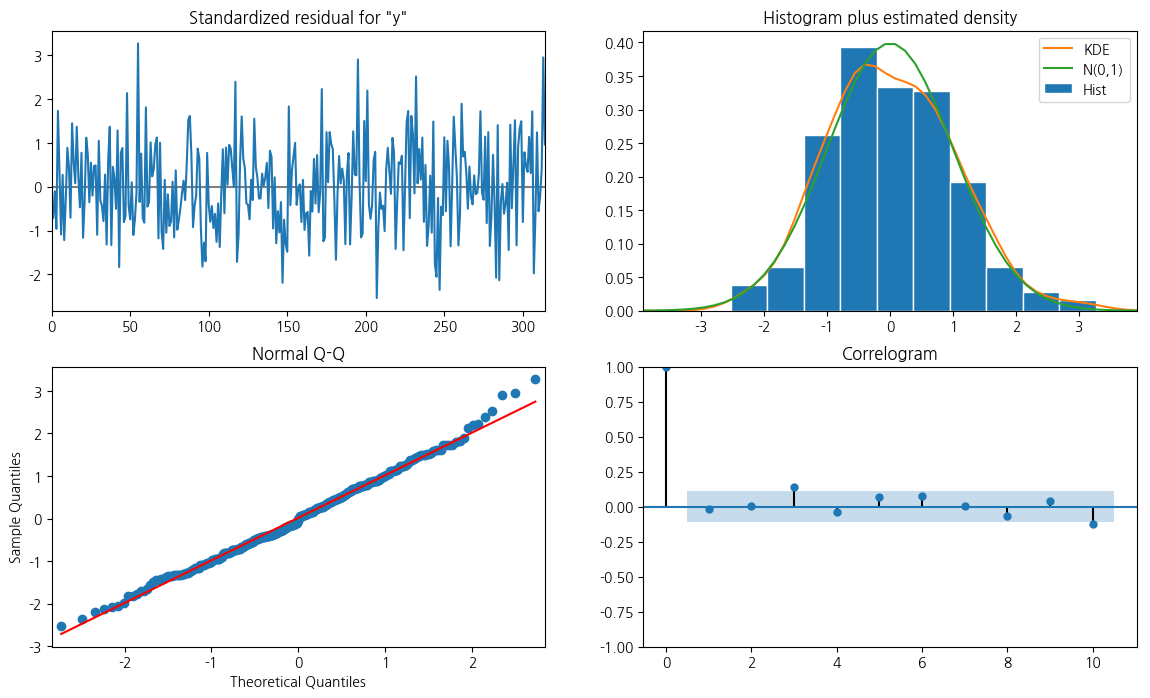

In [499]:
seasonal_model.plot_diagnostics(figsize=(14, 8))
pyplot.show()

In [502]:
# 2. 잔차 추출
resid = seasonal_model.resid

# 4. Ljung-Box test
lb_test = acorr_ljungbox(resid, lags=[12], return_df=True)
print("\nLjung-Box test (lag=10):")
print(lb_test)


Ljung-Box test (lag=10):
       lb_stat     lb_pvalue
12  105.378526  4.888349e-17


데이터에 훨씬 더 잘 부합하는 것으로 보이며, ACF 플롯은 이전 모델만큼 계절성을 강하게 나타내지 않습니다.

# 적합 모델을 비교하는 통계적 방법
- auto.arima매개변수 검색과 각 모델의 아카이케 정보 기준(AIC) 비교를 기반으로 모델을 학습시킬 수 있습니다. 데이터를 전달하기만 하면 auto.arima최적의 모델이 반환된다.

In [345]:
import pmdarima as pm

auto_model = pm.auto_arima(train, start_p=1, start_q=1, # AR(자기회귀) 차수 시작값, MA(이동평균) 차수 시작값
                      test='adf', # adf로 정상성 검정
                      m=12, # frequency of series
                      d=None, # None이면 ADF 검정 결과에 따라 자동으로 선택
                      seasonal=True, # Use Seasonality
                      information_criterion='aicc', # 'aic', 'bic', 'hqic', 'aicc' 중 선택 가능
                      suppress_warnings=True,
                      stepwise=True) #  stepwise (단계적 탐색)으로 빠르게 근사 최적 모형

print(auto_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  341
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 743.925
Date:                            Sat, 30 Aug 2025   AIC                          -1479.849
Time:                                    21:57:39   BIC                          -1464.534
Sample:                                         0   HQIC                         -1473.747
                                            - 341                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3712      0.054     -6.921      0.000      -0.476      -0.266
ar.S.L12       0.9971      0.002   

ARIMA(3,1,0)(1,0,2) 즉, 자기회귀 항, 1번 차분 적용, 계절 자기회귀 성분, 계절 이동 평균을 포함하고 계절 주기가 12시간 단계인 이동 평균 모델이다. 

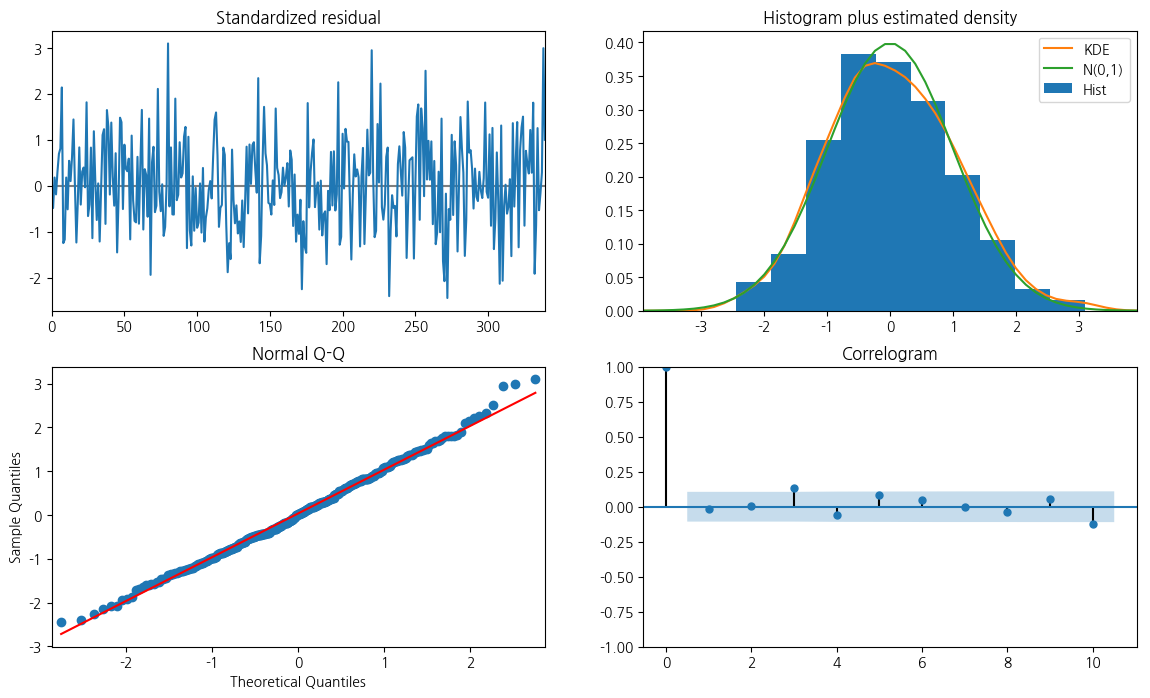

In [346]:
auto_model.plot_diagnostics(figsize=(14, 8))
pyplot.show()

In [503]:
# 2. 잔차 추출
resid = auto_model.resid()

# 4. Ljung-Box test :  잔차는 백색잡음
lb_test = acorr_ljungbox(resid, lags=[12], return_df=True)
print("\nLjung-Box test (lag=12):")
print(lb_test)


Ljung-Box test (lag=10):
     lb_stat  lb_pvalue
12  9.035532   0.699893


# 모델 비교


In [348]:
print("non seasonal fit :", non_seasonal_model.aic)
print("seasonal fit :", seasonal_model.aic)
print("auto-arima fit :", auto_model.aic())

non seasonal fit : -898.326644421043
seasonal fit : -1384.4587205758867
auto-arima fit : -1479.8493496628118


- 계절 모델이 비계절 모델보다 데이터에 훨씬 더 잘 부합하는 것을 알 수 있다.
- 베이지안 정보 기준(BIC)도 모델 비교에 사용되는 경우가 있다.

# 세가지 모델의 예측

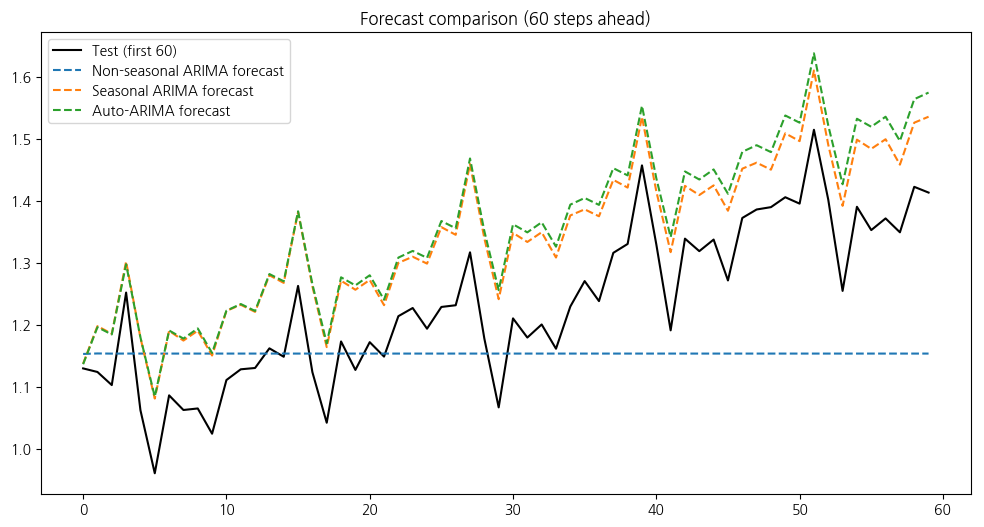

In [349]:
import matplotlib.pyplot as plt
import pandas as pd

h = 60  # 예측 구간

# 1. 예측값 생성
forecast1 = non_seasonal_model.forecast(steps=h)
forecast2 = seasonal_model.forecast(steps=h)
forecast3 = auto_model.predict(n_periods=h)   # pmdarima는 predict 사용


test_h = pd.Series(test[:h]).reset_index(drop=True)

# 3. 시각화
plt.figure(figsize=(12,6))
plt.plot(test_h.values, label="Test (first 60)", color="black")
plt.plot(forecast1, label="Non-seasonal ARIMA forecast", linestyle="--")
plt.plot(forecast2, label="Seasonal ARIMA forecast", linestyle="--")
plt.plot(forecast3, label="Auto-ARIMA forecast", linestyle="--")

plt.title("Forecast comparison (60 steps ahead)")
plt.legend()
plt.show()

단순 비계절 모델은 예측값이 계절 변동을 전혀 포착하지 못하고 빠르게 평균으로 회귀하는 것을 확인할 수 있습니다. 두 계절 모델은 추세값, 즉 계절값이 이전 값에 비해 얼마나 증가할지를 과대 예측하는 경향이 있습니다. 두 모델의 오차항은 예측 기간 내내 꾸준히 증가하고 있습니다.

In [352]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def forecast_accuracy(y_pred, y_true):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape}

# test 데이터 길이 맞추기 (앞의 60개만 사용)
y_true = np.array(test[:h])

acc1 = forecast_accuracy(forecast1, y_true)
acc2 = forecast_accuracy(forecast2, y_true)
acc3 = forecast_accuracy(forecast3, y_true)


print("Non-seasonal ARIMA accuracy:", acc1)
print("Seasonal ARIMA accuracy:", acc2)
print("Auto-ARIMA accuracy:", acc3)

Non-seasonal ARIMA accuracy: {'MSE': 0.02177700890124559, 'RMSE': 0.14757035237894361, 'MAE': 0.11783799606877385, 'MAPE': 9.117227793825274}
Seasonal ARIMA accuracy: {'MSE': 0.012677221958014682, 'RMSE': 0.11259317012152506, 'MAE': 0.10900217483680175, 'MAPE': 8.97159958972578}
Auto-ARIMA accuracy: {'MSE': 0.016426508228789514, 'RMSE': 0.12816594020561592, 'MAE': 0.12419731859378139, 'MAPE': 10.135204158658453}


데이터가 변환되었으므로 비교를 위해 변환되지 않은 예측값이 필요할 수 있습니다. 이 InvBoxCox방법을 사용하면 Box-Cox 변환을 역으로 수행하여 변환되지 않은 값을 얻을 수 있습니다.

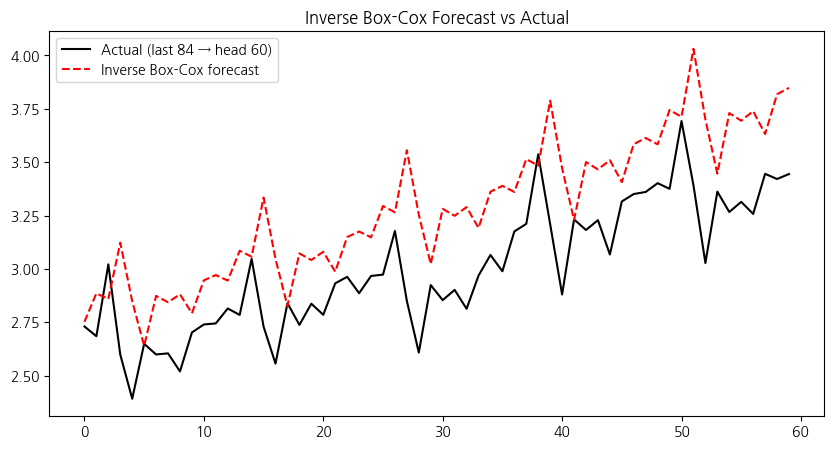

In [353]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import inv_boxcox
from scipy.stats import boxcox_normmax

# 1. Box-Cox λ 추정
lambda_bc = boxcox_normmax(ts)   # df가 원본 시계열 (Series)

test_h = pd.Series(test[:h]).reset_index(drop=True)

# 2. forecast3 (auto-arima 예측값)을 역 Box-Cox 변환
inv = inv_boxcox(forecast3, lambda_bc)

# 3. 실제 데이터 마지막 84개 중 앞 48개만
actual_segment = ts[-84:][:60]

# 4. 시각화
plt.figure(figsize=(10,5))
plt.plot(actual_segment.values, label="Actual (last 84 → head 60)", color="black")
plt.plot(inv, label="Inverse Box-Cox forecast", linestyle="--", color="red")
plt.title("Inverse Box-Cox Forecast vs Actual")
plt.legend()
plt.show()

# 데이터 2

In [519]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23e1e9f0&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1318&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=IPG2211A2N&scale=left&cosd=1939-01-01&coed=2024-03-01&line_color=%234572a7&link_values=false&line_style=solid&mark_type=none&mw=3&lw=2&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2024-05-07&revision_date=2024-05-07&nd=1939-01-01"

# change for your uploaded URL
df = pd.read_csv(url)
df.columns = ['date', 'production']
df['date'] = pd.to_datetime(df['date'])
df = df.set_index(df['date']).drop('date', axis=1)
df.head()

,production
date,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608


In [520]:
df = df.resample("MS").last()
df

,production
date,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608
...,...
2023-11-01,99.4709
2023-12-01,108.6596
2024-01-01,124.2325


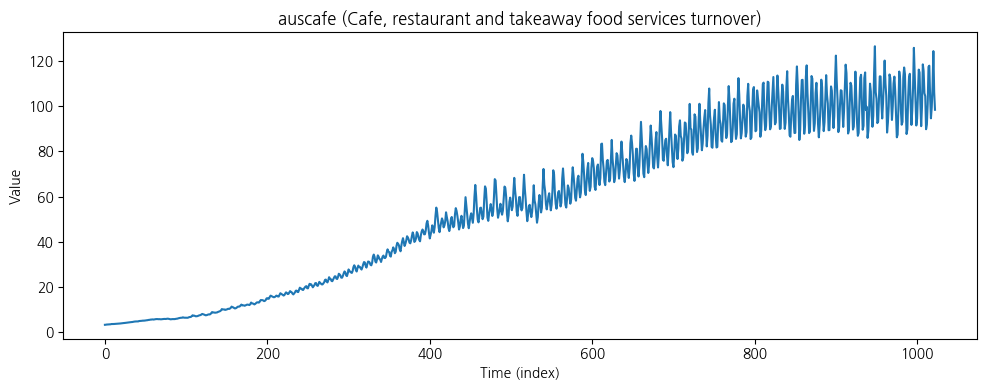

In [523]:
import matplotlib.pyplot as plt

# 3) 단순 라인 플롯 (시계열 인덱스가 없으면 정수 인덱스로 그림)
plt.figure(figsize=(10,4))
plt.plot(df.values)
plt.title("auscafe (Cafe, restaurant and takeaway food services turnover)")
plt.xlabel("Time (index)")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

강한 추세와 계절성을 보이며, 계절적 변동과 무작위 변동의 크기가 시계열 수준에 따라 증가하는 것으로 보인다.

# 추세와 계절성의 강도 측정

$y_t = T_t + S_t + R_t$
- $T_t$: 평활된 추세(trend)
- $S_t$: 계절성(seasonal) (각 계절 내 평균이 0이 되도록 추정)
- $R_t$: 나머지(잔차)(remainder)
---
1.	추세의 강도
$$
F_T=\max\!\left(0,\;1-\frac{\mathrm{Var}(R_t)}{\mathrm{Var}(T_t+R_t)}\right)
$$
- $F_T$가 1에 가까울수록 추세가 강함
---
2.	계절성의 강도
$$
F_S=\max\!\left(0,\;1-\frac{\mathrm{Var}(R_t)}{\mathrm{Var}(S_t+R_t)}\right)
$$
- $F_S$가 1에 가까울수록 계절성이 강함(추세 제거 후 변동의 상당 부분이 계절성).

In [510]:
from statsmodels.tsa.seasonal import STL

def strength_trend_seasonality(ts: pd.Series, period: int):
    """
    ts: DatetimeIndex/PeriodIndex를 가진 시계열 (가법 가정)
    period: 계절 주기 (월별=12, 분기=4, 주별=52 등)
    """
    res = STL(ts, period=period, robust=True).fit()
    comp = pd.DataFrame({
        "trend": res.trend,
        "seasonal": res.seasonal,
        "resid": res.resid
    }).dropna()

    T, S, R = comp["trend"], comp["seasonal"], comp["resid"]
    y_sa = ts.loc[comp.index] - S          # 계절조정 = T + R
    y_dt = ts.loc[comp.index] - T          # 추세제거 = S + R

    var = lambda x: np.var(x, ddof=1)
    var_R  = var(R)
    var_TR = var(y_sa)
    var_SR = var(y_dt)

    # 0으로 나누기 방지
    eps = 1e-12
    FT = max(0.0, 1.0 - (var_R / max(var_TR, eps)))
    FS = max(0.0, 1.0 - (var_R / max(var_SR, eps)))
    return FT, FS, comp  # comp로 T,S,R도 확인 가능

# 예: 월별 데이터(period=12)
FT, FS, components = strength_trend_seasonality(df['production'], period=12)
print(f"추세 강도 FT={FT:.3f}, 계절 강도 FS={FS:.3f}")

추세 강도 FT=0.998, 계절 강도 FS=0.910


# 정상성 확인

In [511]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df.values)
print(adf_result[1])
print("ADF 검정을 실행할 때 검정 통계량이 임계값보다 작고 p-값이 0.05보다 작으면 귀무가설을 기각하여 시계열이 정상적임을 의미합니다.")
print("ADF 검정 값이 0.05보다 높으므로 데이터가 현재 정상 상태가 아님을 알 수 있다. KPSS 검정을 실행하면 이를 확인하는 데 도움이 될 수 있다.")

0.8064038372457238
ADF 검정을 실행할 때 검정 통계량이 임계값보다 작고 p-값이 0.05보다 작으면 귀무가설을 기각하여 시계열이 정상적임을 의미합니다.
ADF 검정 값이 0.05보다 높으므로 데이터가 현재 정상 상태가 아님을 알 수 있다. KPSS 검정을 실행하면 이를 확인하는 데 도움이 될 수 있다.


In [512]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(df.values)
print(kpss_result[1])

0.01


KPSS 검정은 KPSS 검정 결과가 0.05 미만이기 때문에 시계열이 정상적이지 않다는 것을 나타냅니다.

두 검정 결과가 일치하거나 일치하지 않으면 혼란스러울 수 있습니다. KPSS와 ADF가 시계열이 정상적이라고 동의하면 정상적이라고 간주할 수 있으며, ARIMA 모형에서 차분항을 사용할 필요가 없습니다.

diff방법을 사용하여 시계열을 차분하거나, Box-Cox 변환을 통해 추세를 제거할 수 있습니다.


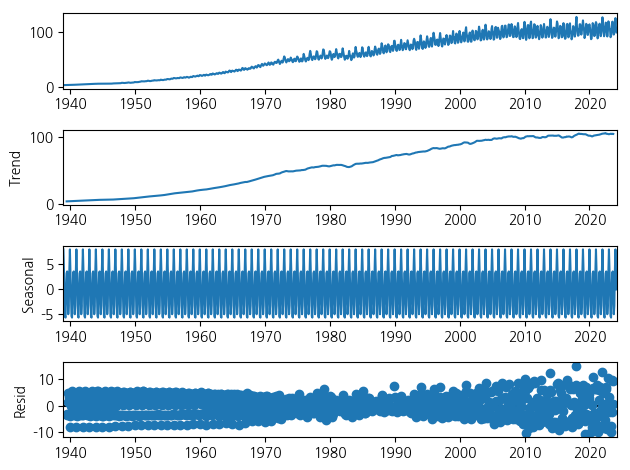

In [513]:
# 덧셈분해
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df, model='additive')
result.plot()
pyplot.show()

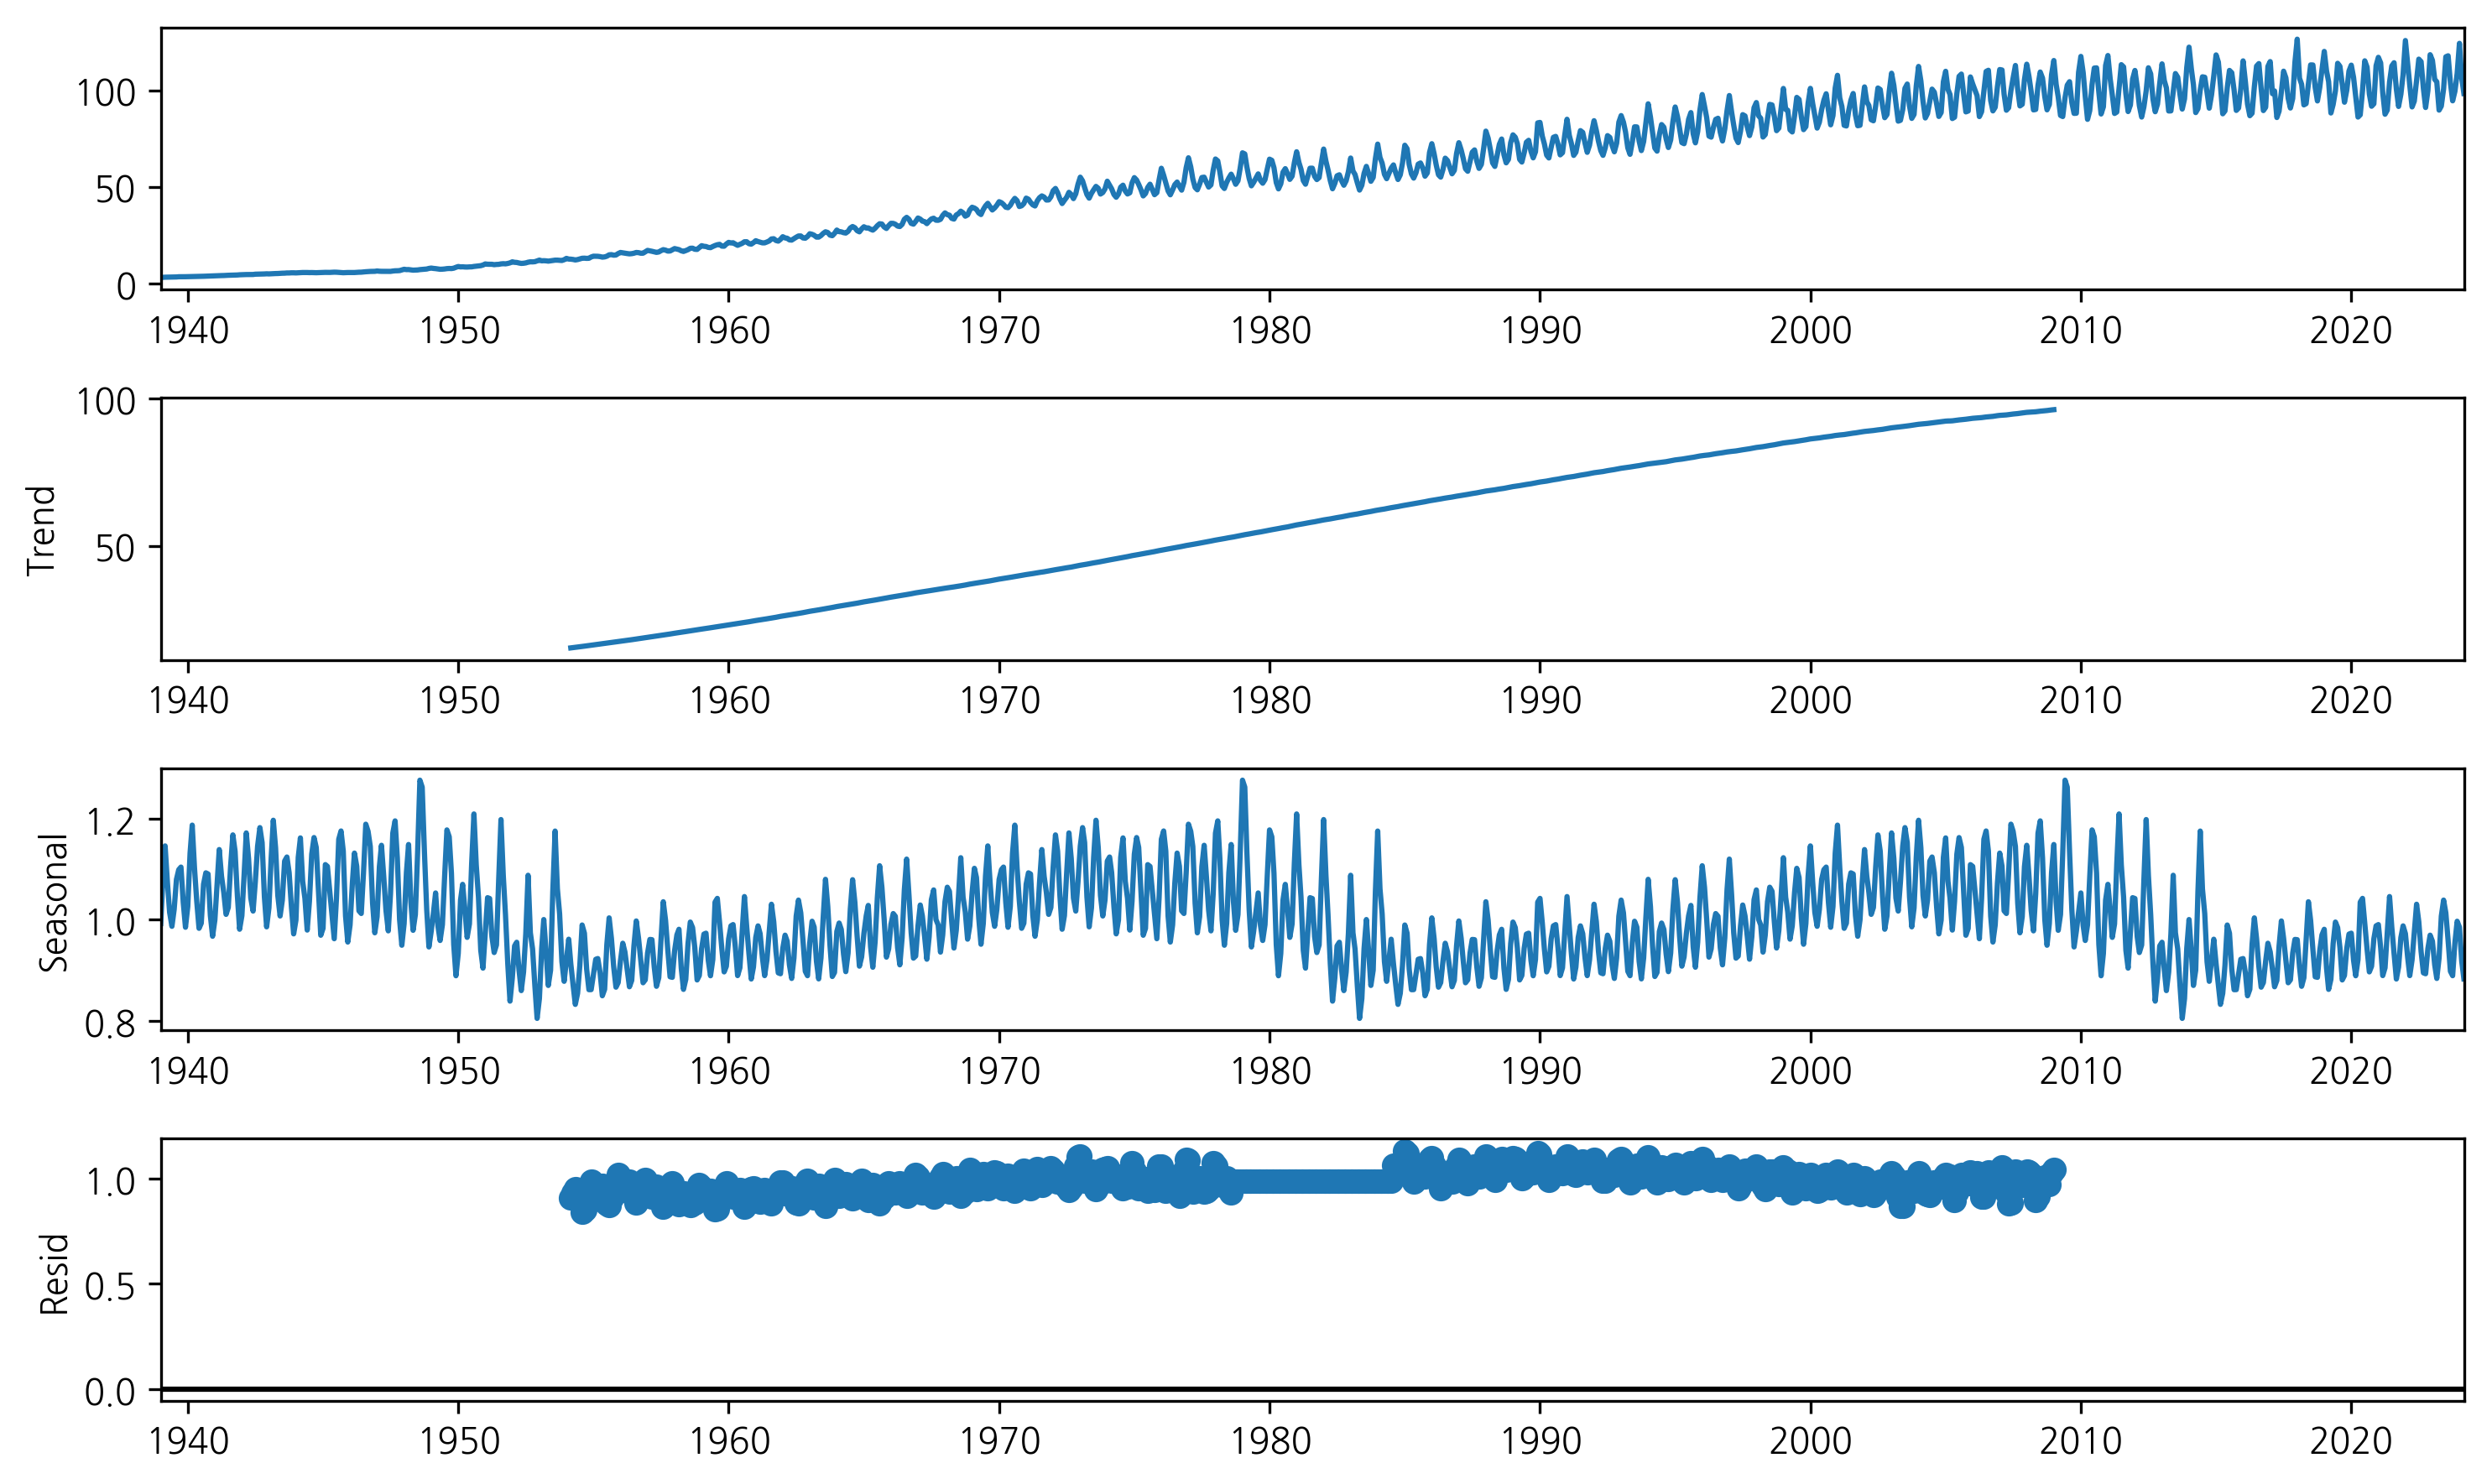

In [524]:
# 곱셈 분해
decomposition = sm.tsa.seasonal_decompose(df, model='multiplicative', period=365)
fig = decomposition.plot()
fig.set_dpi(300)
fig.set_tight_layout('constrained')
fig.set_size_inches(10, 6)
plt.show()

- 강력한 추세와 계절성이 존재함.
- 시계열의 분산이 시간이 지남에 따라 증가하는 것을 확인할 수 있습니다. ARIMA 모델은 계절성과 비정상성을 잘 처리하지만, 분산 변화나 이분산성을 특히 잘 처리하지는 못한다.-> **로그변환**

In [515]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox

df['production'],fitted_lambda= boxcox(df['production'],lmbda=None)

In [516]:
ts_diff = df['production'].diff().dropna()

FT, FS, components = strength_trend_seasonality(ts_diff, period=12)
print(f"변환된 추세 강도 FT={FT:.3f}, 변환된 계절 강도 FS={FS:.3f}")

변환된 추세 강도 FT=0.000, 변환된 계절 강도 FS=0.889


In [485]:
ts_diff_seasonal = ts_diff.diff(12).dropna()  # 계절 차분 
FT, FS, components = strength_trend_seasonality(ts_diff_seasonal, period=12)
print(f"변환된 추세 강도 FT={FT:.3f}, 변환된 계절 강도 FS={FS:.3f}")

변환된 추세 강도 FT=0.000, 변환된 계절 강도 FS=0.000


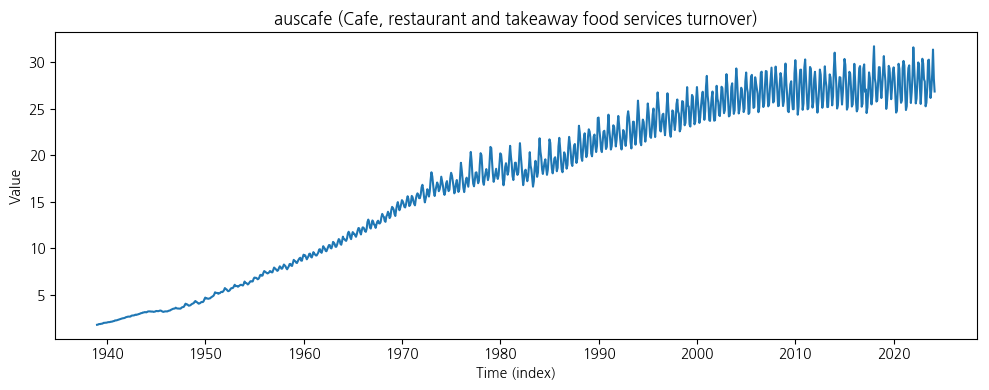

In [517]:
import matplotlib.pyplot as plt
ts = df['production']

# 3) 단순 라인 플롯 (시계열 인덱스가 없으면 정수 인덱스로 그림)
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.title("auscafe (Cafe, restaurant and takeaway food services turnover)")
plt.xlabel("Time (index)")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# 곱셈분해
- 시계열 데이터가 비선형적인 형태, 특히 시간이 지남에 따라 계절적 효과가 증가하거나 감소하는 경우에 적합합니다.
- 즉, 데이터에서의 추세, 계절성, 그리고 잔차가 곱해져 원래의 시계열 데이터를 구성한다는 가정입니다.
- 데이터에 0이 존재해서는 안됩니다.

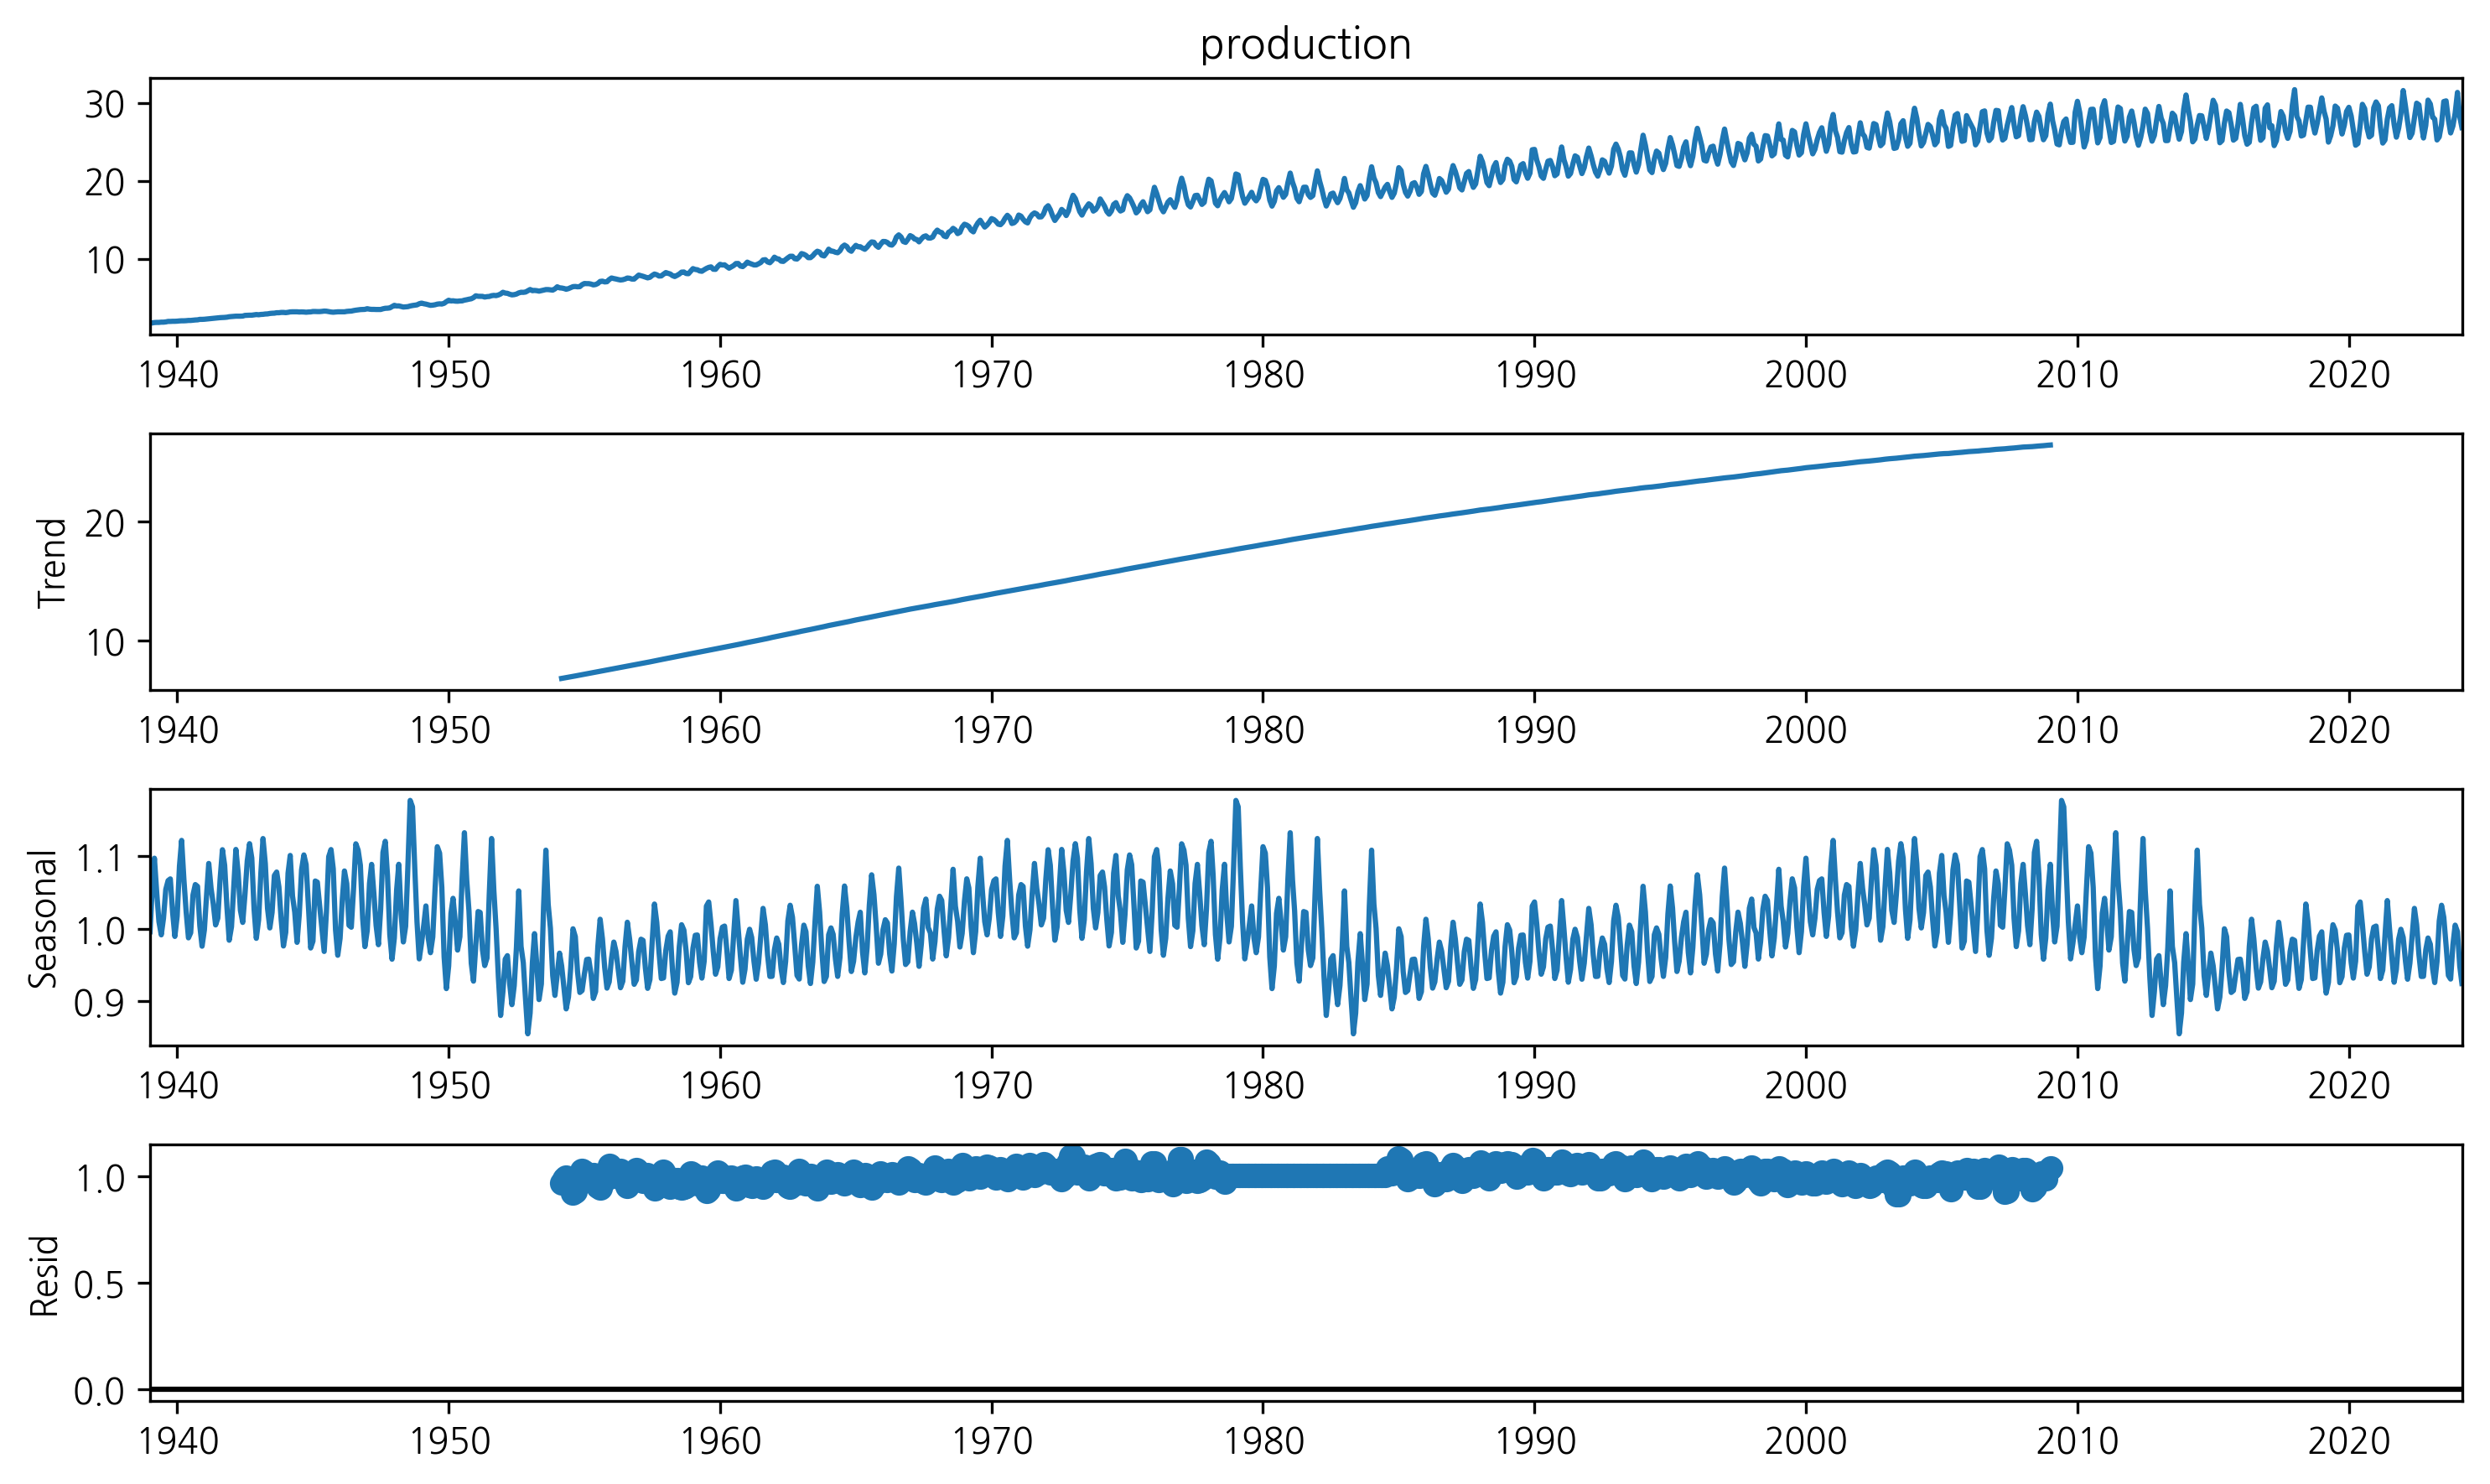

In [518]:
decomposition = sm.tsa.seasonal_decompose(ts, model='multiplicative', period=365)
fig = decomposition.plot()
fig.set_dpi(300)
fig.set_tight_layout('constrained')
fig.set_size_inches(10, 6)
plt.show()

추세는 여전히 존재하지만 분산이 충분히 감소했다.

자기 상관관계 플롯

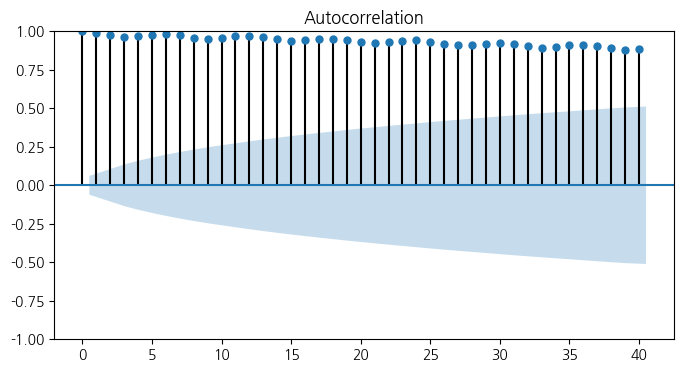

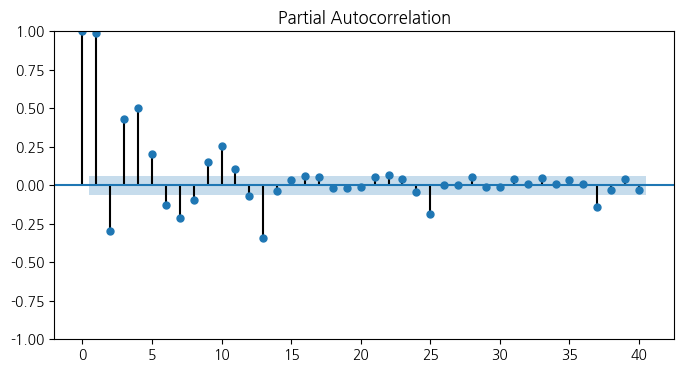

In [446]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

# transform 이 pandas Series 또는 ndarray라고 가정
fig, ax = plt.subplots(figsize=(8,4))
plot_acf(ts, lags=40, ax=ax)  # lags=40은 최대 지연 시차 (필요시 조정)
plt.show()

# transform 이 pandas Series 또는 ndarray라고 가정
fig, ax = plt.subplots(figsize=(8,4))
plot_pacf(ts, lags=40, method='ywm', ax=ax)  # lags 조정 가능
plt.show()

In [447]:
import pandas as pd

# test_size = 36
train = df.iloc[:-36]   # 마지막 36개 제외
test = df.iloc[-36:]    # 마지막 36개만

In [448]:
train

,production
date,
1939-01-01,1.799875
1939-02-01,1.816152
1939-03-01,1.864585
1939-04-01,1.880619
1939-05-01,1.880619
...,...
2020-11-01,25.867114
2020-12-01,29.386639
2021-01-01,30.129603


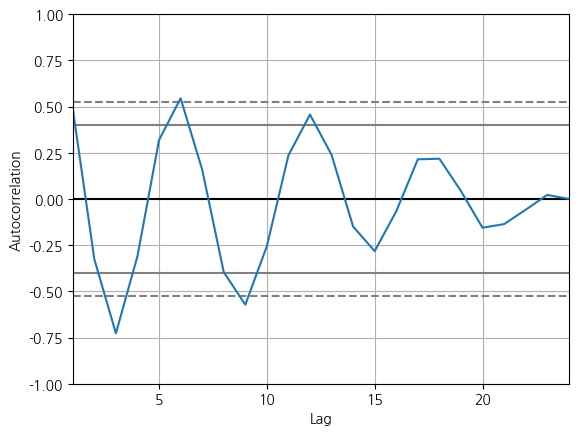

In [449]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(train[-24:]) # 24개만
pyplot.show()

- 24개 시간 단위에 걸쳐, 추세 제거된 시계열은 시차 6, 12, 18에서 여전히 양의 상관관계를 보이지만 감소하는 추세를, 시차 3, 9, 15에서는 음의 상관관계를 보입니다.
- 이는 시계열에 여전히 계절성 요소가 있음을 나타냅니다. 
- 하지만 0.5에서 -0.5까지의 임계 범위를 벗어나는 유일한 시계열은 3이므로, 이는 ARIMA 모델의 자기회귀 요소 값을 나타낼 수 있습니다.

PACF는 ARIMA 모형의 AR 부분의 차수를 결정하는 데 유용합니다. 또한 계절 시계열에 대한 이동 평균 기반 예측 모형의 예측 방정식에 얼마나 많은 계절 시차를 포함할지 결정하거나 검증하는 데에도 유용합니다. 이를 계절 이동 평균(SMA) 차수라고 합니다.

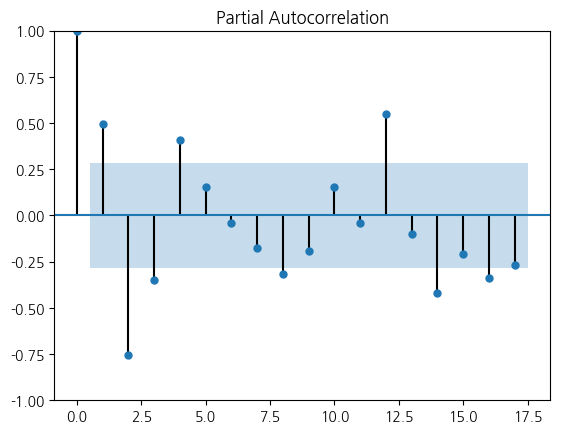

In [450]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(train[-48:])
pyplot.show()

 0.5에서 -0.5의 임계 범위를 벗어난 값은 4이므로 이는 ARIMA 모델의 자기회귀 구성 요소에 대한 값을 나타냅니다.

두 플롯에서 ACF 플롯이 시차 1에서 양의 값을 보이고 PACF가 다소 빠르게 감소하는 것을 확인할 수 있습니다. 이는 모델에 AR 항을 사용해야 함을 시사합니다.

In [451]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(4,1,0))
model_fit = model.fit()

In [452]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             production   No. Observations:                  987
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -899.196
Date:                Sat, 30 Aug 2025   AIC                           1806.391
Time:                        22:36:11   BIC                           1825.966
Sample:                    01-01-1939   HQIC                          1813.836
                         - 03-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2336      0.018     13.347      0.000       0.199       0.268
ar.L2         -0.2893      0.015    -19.329      0.000      -0.319      -0.260
ar.L3         -0.5838      0.016    -36.738      0.0

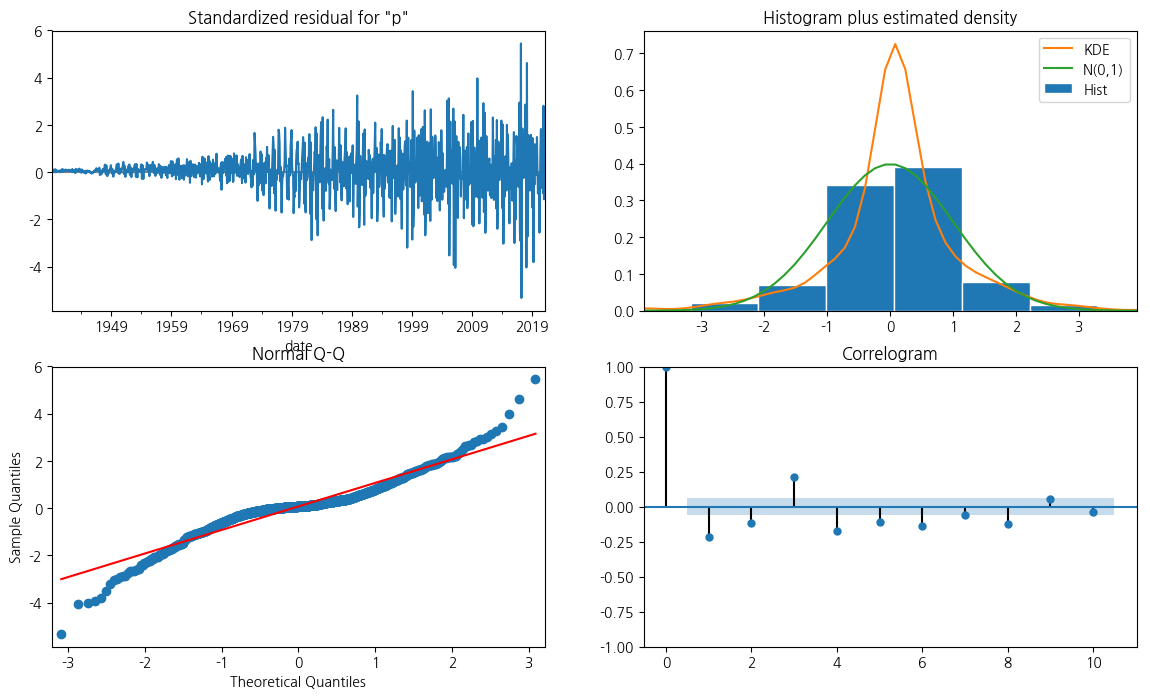

In [453]:
model_fit.plot_diagnostics(figsize=(14, 8))
pyplot.show()

- 분산이 증가함에 따라 잔차도 증가하는 것을 볼 수 있지만, 이는 단순히 데이터의 특성일 수 있습니다. 
- 이제 적합 모델의 예측력이 검정 데이터와 얼마나 일치하는 지 확인

In [454]:
resid = model_fit.resid

# -----------------------------
# 4) Ljung-Box 검정 (12, 24 시차)
# -----------------------------
lb_test = acorr_ljungbox(resid, lags=[12,24], return_df=True)
print("\nLjung-Box test (원래 모형)")
print(lb_test)


Ljung-Box test (원래 모형)
       lb_stat      lb_pvalue
12  518.022301  3.226488e-103
24  791.621792  1.215990e-151


In [455]:
history = train
predictions = list()
# walk-forward validation
for t in range(len(test),0,-1):
    model = ARIMA(df[:-t], order=(3,1,0));
    model_fit = model.fit();
    output = model_fit.forecast();
    yhat = output.iloc[0]
    predictions.append(yhat)

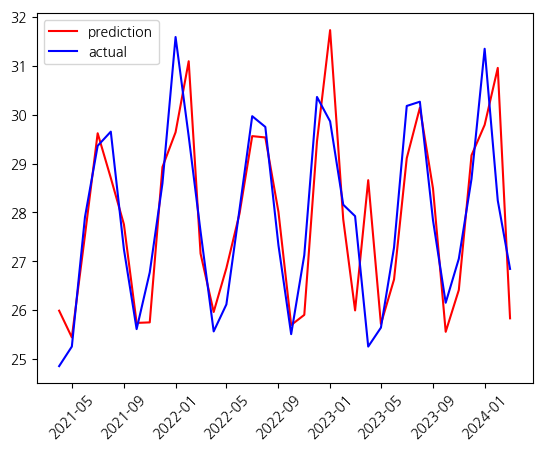

In [456]:
test.loc[:,'predictions'] = predictions.copy()

pyplot.plot(test['predictions'], color='red', label='prediction')
pyplot.plot(test['production'], color='blue', label='actual')
pyplot.legend(loc="upper left")
pyplot.xticks(rotation=45)
pyplot.show()

In [457]:
test

,production,predictions
date,,
2021-04-01,24.857845,25.991543
2021-05-01,25.258079,25.446142
2021-06-01,27.906257,27.534485
2021-07-01,29.363863,29.620580
2021-08-01,29.653196,28.706339
2021-09-01,27.246762,27.756990
2021-10-01,25.614630,25.741667
2021-11-01,26.775120,25.752448
2021-12-01,28.595542,28.929472


In [458]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# evaluate forecasts
rmse = sqrt(mean_squared_error(test['predictions'], test['production']))
print('Test RMSE: %.3f' % rmse)

Test RMSE: 1.138


모델이 다루지 않는 한 가지 특징은 계절성입니다. ARIMA 모델을 생성하는 또 다른 방법은 모델을 자동으로 생성하는 Auto ARIMA 구현을 사용하는 것입니다.

# pmdarima 라이브러리
- ARIMA 모델에 가장 적합한 매개변수를 식별하고 단일 적합 ARIMA 모델을 선택하는 자동 ARIMA 프로세스에 대한 액세스를 제공

In [233]:
import pmdarima as pm

auto_model = pm.auto_arima(train, start_p=1, start_q=1, # AR(자기회귀) 차수 시작값, MA(이동평균) 차수 시작값
                      test='adf', # adf로 정상성 검정
                      m=12, # frequency of series
                      d=None, # None이면 ADF 검정 결과에 따라 자동으로 선택
                      seasonal=True, # Use Seasonality
                      information_criterion='aicc', # 'aic', 'bic', 'hqic', 'aicc' 중 선택 가능
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True) #  stepwise (단계적 탐색)으로 빠르게 근사 최적 모형

In [234]:
print(auto_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  987
Model:             SARIMAX(1, 1, 2)x(2, 0, 2, 12)   Log Likelihood                -338.719
Date:                            Sat, 30 Aug 2025   AIC                            693.437
Time:                                    20:46:42   BIC                            732.586
Sample:                                01-01-1939   HQIC                           708.327
                                     - 03-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4837      0.046     10.405      0.000       0.393       0.575
ma.L1         -0.8400      0.049   

- 최종 모형은 SARIMAX(1, 1, 2)x(2, 0, 2, 12)
- 비계절: ARIMA(p=1, d=1, q=2) 한 번 차분(d=1)한 시계열에 AR(1)과 MA(2).
- 계절(주기 s=12 가정): (P=2, D=0, Q=2) → 12, 24개월 지연의 계절 AR 2개와 계절 MA 2개, 계절 차분은 없음(D=0).
---
--------- 추정치 ---- pvalue---------
- ar.L1 : +0.484  <0.001    (차분한) 현재 변화가 직전 변화에 양(+)의 관성.
- ma.L1 : −0.840  <0.001     강한 단기 음(-) 충격 보정.
- ma.L2 : −0.083   0.034     약한 2시차 보정도 유의.
- ar.S.L12 : +0.595  <0.001    12개월 주기의 계절적 관성 뚜렷.
- ar.S.L24 : +0.399   0.010    24개월(2년) 영향도 유의.
- ma.S.L12 : −0.208   **0.178    비유의 → 단순화 후보.**
- ma.S.L24 :  −0.394  <0.001    24개월 계절 MA 영향 유의.
- sigma²  : 0.1125    <0.001    잔차 분산(모형 오차의 평균제곱). 작을수록 적합이 좋음.
---
- 	Log Likelihood = −338.7, AIC = 693.4, BIC = 732.6, HQIC = 708.3 → 절대값 자체보다 **대안 모델과의 상대 비교가 중요**
---
- 잔차 진단(요약 테이블 하단)
	- Ljung–Box (L1) Q=0.00, p=0.98
    - → 1시차 기준으로는 자기상관이 없음. 

- Jarque–Bera p=0.00, Kurtosis=5.93, Skew≈−0.02
    - → 잔차 분포가 **뾰족/두터운 꼬리(고쿠르토시스)**로 정규성 위반. 평균 예측은 괜찮더라도 예측구간이 과도하게 낙관적일 수 있어요.
- Heteroskedasticity H=42.82, p=0.00
    - → 이분산 존재(분산이 시점에 따라 달라짐). 마찬가지로 신뢰구간 신뢰성에 영향.

생성된 SARIMA 모델의 AIC는 이전에 생성한 비계절 모델의 절반보다 적다. 이는 계절적 요소가 모델링에 중요한 특징임을 시사한다.

In [224]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# -----------------------------
# 1) 원래 모형 (비교용)
# -----------------------------
model_full = sm.tsa.SARIMAX(
    df, order=(1,1,2), seasonal_order=(2,0,2,12),
    enforce_stationarity=False, enforce_invertibility=False
).fit()

print("원래 모형 AIC:", model_full.aic)
print("원래 모형 BIC:", model_full.bic)
print(model_full.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            8     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.40039D-01    |proj g|=  8.46719D-01


 This problem is unconstrained.



At iterate    5    f=  4.37854D-01    |proj g|=  5.70086D-01

At iterate   10    f=  3.72833D-01    |proj g|=  1.70153D-01

At iterate   15    f=  3.72242D-01    |proj g|=  1.54721D-02

At iterate   20    f=  3.71237D-01    |proj g|=  5.77353D-02

At iterate   25    f=  3.70082D-01    |proj g|=  1.94873D-02

At iterate   30    f=  3.70057D-01    |proj g|=  2.67293D-04

At iterate   35    f=  3.70056D-01    |proj g|=  6.16716D-03

At iterate   40    f=  3.70052D-01    |proj g|=  3.79411D-03

At iterate   45    f=  3.70051D-01    |proj g|=  6.85942D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    8     49     58   

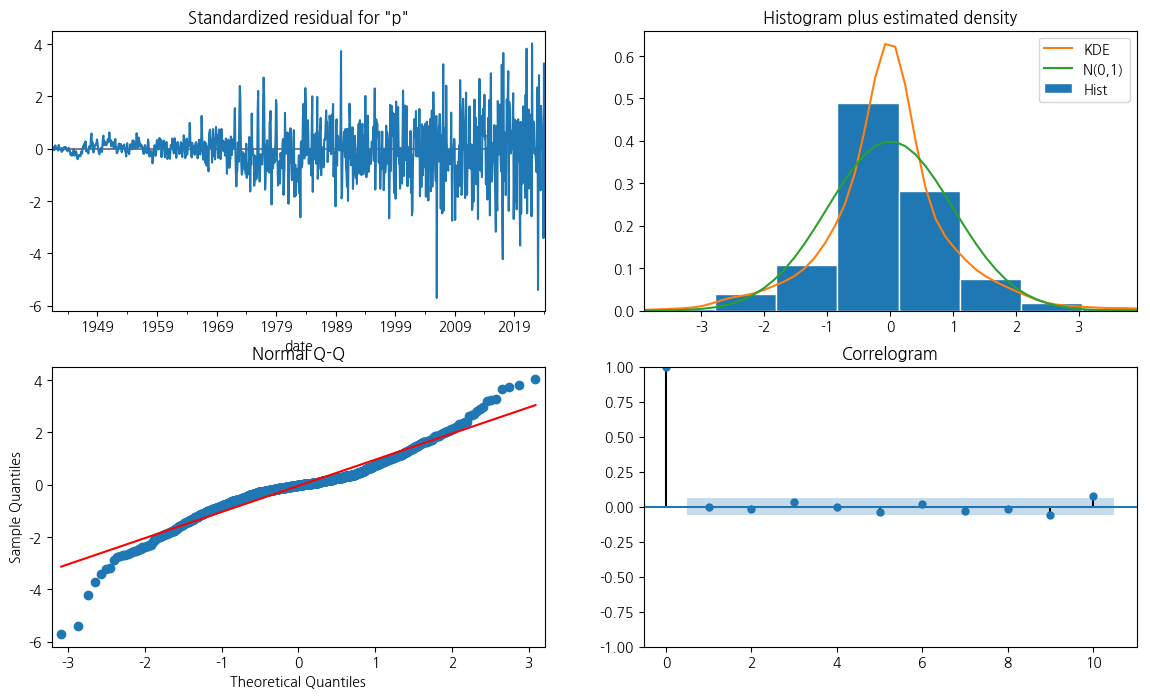

In [237]:
model_full.plot_diagnostics(figsize=(14, 8))
pyplot.show()

In [227]:
resid = model_full.resid

# -----------------------------
# 4) Ljung-Box 검정 (12, 24 시차)
# -----------------------------
lb_test = acorr_ljungbox(resid.dropna(), lags=[12,24], return_df=True)
print("\nLjung-Box test (원래 모형)")
print(lb_test)


Ljung-Box test (원래 모형)
      lb_stat  lb_pvalue
12  22.972101   0.027964
24  48.668149   0.002084


In [225]:
# -----------------------------
# 2) 단순 모형 (ma.S.L12 제거)
# seasonal_order=(2,0,1,12) 로 변경
# -----------------------------
model_simplified = sm.tsa.SARIMAX(
    df, order=(1,1,2), seasonal_order=(2,0,1,12),
    enforce_stationarity=False, enforce_invertibility=False
).fit()

print("단순 모형 AIC:", model_simplified.aic)
print("단순 모형 BIC:", model_simplified.bic)
print(model_simplified.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.38085D-01    |proj g|=  8.45411D-01


 This problem is unconstrained.



At iterate    5    f=  3.94036D-01    |proj g|=  4.68609D-01

At iterate   10    f=  3.80552D-01    |proj g|=  9.13143D-02

At iterate   15    f=  3.75718D-01    |proj g|=  5.74473D-02

At iterate   20    f=  3.75409D-01    |proj g|=  8.46767D-02

At iterate   25    f=  3.74255D-01    |proj g|=  1.10238D-02

At iterate   30    f=  3.74254D-01    |proj g|=  6.38575D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     33     42      1     0     0   9.580D-05   3.743D-01
  F =  0.37425346117200942     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
단순 모형 AIC: 779.7225815579312
단순 모형 BIC: 814.0558369

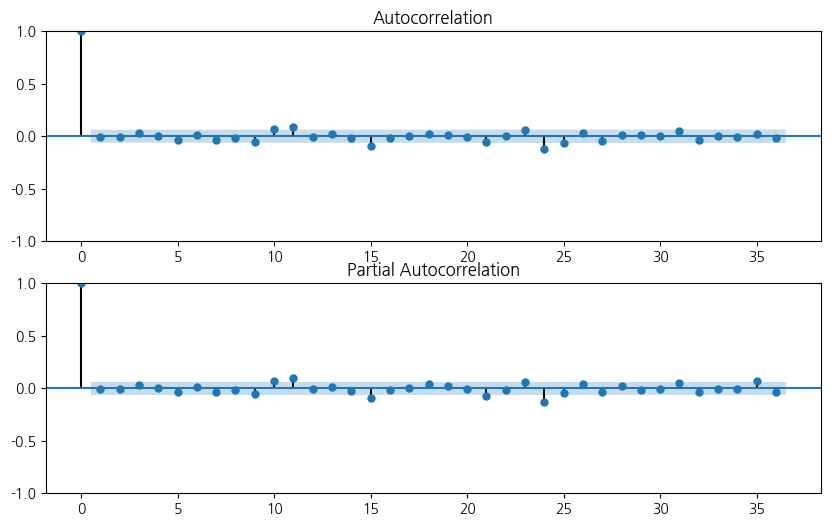


Ljung-Box test (단순 모형)
      lb_stat  lb_pvalue
12  21.659211   0.041522
24  53.657082   0.000473


In [221]:
# -----------------------------
# 3) 잔차 ACF/PACF 시각화
# -----------------------------
resid = model_simplified.resid

fig, ax = plt.subplots(2, 1, figsize=(10,6))
sm.graphics.tsa.plot_acf(resid.dropna(), lags=36, ax=ax[0])
sm.graphics.tsa.plot_pacf(resid.dropna(), lags=36, ax=ax[1])
plt.show()

# -----------------------------
# 4) Ljung-Box 검정 (12, 24 시차)
# -----------------------------
lb_test = acorr_ljungbox(resid.dropna(), lags=[12,24], return_df=True)
print("\nLjung-Box test (단순 모형)")
print(lb_test)

1. 단순 모형((2,0,1,12))의 AIC/BIC가 원래 모형과 비슷하다. 
2. 잔차 ACF, PACF 에 유의한 자기 상관이 없다. 
3. Ljung–Box test에서 시차 12는 p-value값이 0.04로 올라갔다. 

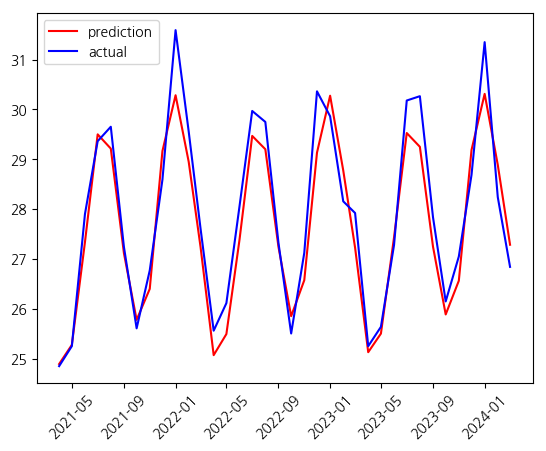

In [240]:
history = train
auto_predictions = auto_model.predict(len(test))

test.loc[:, 'auto_predictions'] = auto_predictions.copy()

pyplot.plot(test['auto_predictions'], color='red', label='prediction')
pyplot.plot(test['production'], color='blue', label='actual')
pyplot.legend(loc="upper left")
pyplot.xticks(rotation=45)
pyplot.show()

In [241]:
# evaluate forecasts
rmse = sqrt(mean_squared_error(test['auto_predictions'], test['production']))
print('Test RMSE: %.3f' % rmse)

Test RMSE: 0.576


RMSE를 확인하면 RMSE가 0.587로 비계절 모델의 절반보다 낮아졌다. 계절별 ARIMA 모델의 RMSE가 비계절별 ARIMA 모델의 RMSE보다 훨씬 작다

# 단순한 예측 기법 
- **역할**
- 때때로 이런 단순한 기법 중의 하나가 사용할 수 있는 가장 좋은 예측 기법이 될 수 있다. 하지만, 많은 경우에 벤치마크 역할을 한다. 즉, ARIMA, 새로운 모델이 이런 단순한 기법보다 좋은지 확인하기 위한 역할이다. 

1. 평균기법 
$$
\hat{y}{T+h|T} = \bar{y} = \frac{y{1} + y_{2} + \cdots + y_{T}}{T}
$$
- 모든 미래 값은 과거 데이터의 평균과 같다. 
---
2. 단순 기법(naïve method)
$$
\hat{y}_{T+h|T} = y_T
$$
- 마지막 값으로 모든 예측값을 둔다.
- 데이터가 확률보행(random walk) 패턴을 따를 때 최적
---
3. 계절성 단순 기법(Seasonal naïve method)
$$
\hat{y}{T+h|T} = y{T+h-m(k+1)}
$$
- m: 주기(계절 주기, 예: 월별 데이터에서 m=12, 분기별이면 m=4)
- k = (h-1)/m의 가우시안 + 1
-  각 예측값을 연도의 같은 계절의(예를 들면, 이전 연도의 같은 달) 마지막 관측값으로 둔다.
---
4. 표류 기법
- 단순 기법(naïve method)을 수정하여 예측값이 시간에 따라 증가하거나 감소하도록 한다.
$$
\hat{y}{T+h|T}
= y_T + \frac{h}{T-1} \sum{t=2}^{T} (y_t - y_{t-1})
= y_T + h \cdot \frac{y_T - y_1}{T-1}.
$$

In [459]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset

# 1) ausbeer 불러와서 분기 시계열로 변환
df = get_rdataset("ausbeer", "fpp2").data  # columns: time, value
# fpp2의 ausbeer는 1956 Q1부터 분기 데이터
idx = pd.period_range(start="1956Q1", periods=len(df), freq="Q")
beer = pd.Series(df["value"].values, index=idx)
beer.name = "ausbeer"

In [460]:
beer

1956Q1    284
1956Q2    213
1956Q3    227
1956Q4    308
1957Q1    262
         ... 
2009Q2    398
2009Q3    419
2009Q4    488
2010Q1    414
2010Q2    374
Freq: Q-DEC, Name: ausbeer, Length: 218, dtype: int64

In [461]:
# 2) 학습 구간: 1992 ~ 2007 Q4
beer2 = beer.loc["1992":"2007Q4"]

In [462]:
beer2

1992Q1    443
1992Q2    410
1992Q3    420
1992Q4    532
1993Q1    433
         ... 
2006Q4    491
2007Q1    427
2007Q2    383
2007Q3    394
2007Q4    473
Freq: Q-DEC, Name: ausbeer, Length: 64, dtype: int64

In [468]:
# 3) 예측 함수들 구현
def meanf(series, h):
    """과거 평균으로 h-스텝 상수 예측"""
    return np.full(h, series.mean(), dtype=float)

def naive(series, h):
    """마지막 관측치 반복"""
    return np.full(h, series.iloc[-1], dtype=float)


def rwf(series, h, drift=False):
    last = series.iloc[-1]
    if not drift:
        # 단순 naive
        return np.full(h, last, dtype=float)
    else:
        # 표류(drift): 기울기 * step 만큼 더해줌
        slope = (series.iloc[-1] - series.iloc[0]) / (len(series)-1)
        steps = np.arange(1, h+1)
        return last + slope * steps

def snaive(series, h, sp=4):
    """계절성 단순 예측: 마지막 한 시즌 패턴 반복"""
    last_season = series.iloc[-sp:].to_numpy()
    reps = int(np.ceil(h / sp))
    fc = np.tile(last_season, reps)[:h]
    return fc.astype(float)

In [469]:
# 4) 예측 지수(미래 분기 인덱스)와 h 설정
h = 11
future_idx = pd.period_range(beer2.index[-1] + 1, periods=h, freq=beer2.index.freq)

# 5) 각 방법 예측치 계산
fc_mean  = pd.Series(meanf(beer2, h), index=future_idx, name="평균")
fc_naive = pd.Series(naive(beer2, h),  index=future_idx, name="단순")
fc_drift = pd.Series(rwf(beer2, h, drift=True),  index=future_idx, name="표류")
fc_snv   = pd.Series(snaive(beer2, h, sp=4), index=future_idx, name="계절성 단순")

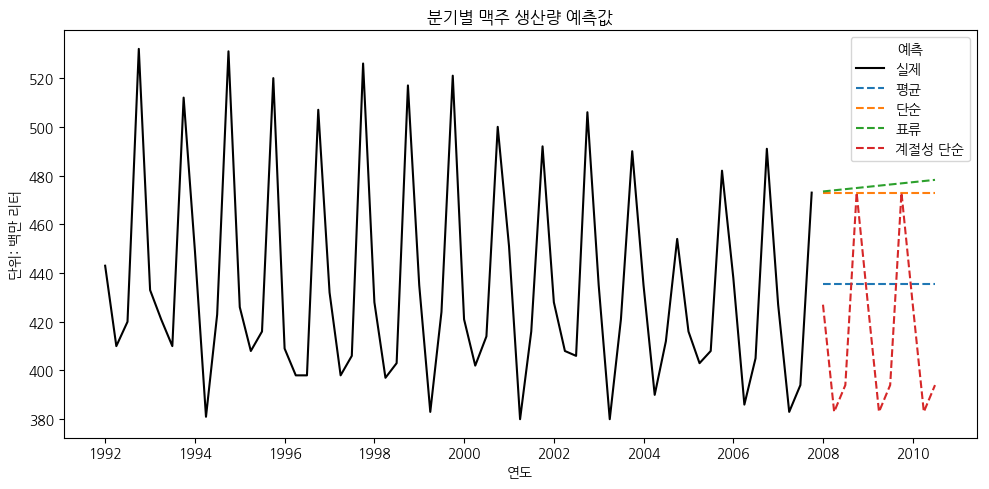

In [470]:
# 6) 시각화
plt.figure(figsize=(10,5))
# 실제(학습) 구간
plt.plot(beer2.index.to_timestamp(), beer2.values, label="실제", color="black")

# 예측 라인들 (PI 없이)
plt.plot(fc_mean.index.to_timestamp(),  fc_mean.values,  label="평균", linestyle="--")
plt.plot(fc_naive.index.to_timestamp(), fc_naive.values, label="단순", linestyle="--")
plt.plot(fc_drift.index.to_timestamp(), fc_drift.values, label="표류", linestyle="--")
plt.plot(fc_snv.index.to_timestamp(),   fc_snv.values,   label="계절성 단순", linestyle="--")

plt.title("분기별 맥주 생산량 예측값")
plt.xlabel("연도")
plt.ylabel("단위: 백만 리터")
plt.legend(title="예측")
plt.tight_layout()
plt.show()